**Gerekli Kurulumlar**

In [ ]:
!pip install optuna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import optuna
import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings('ignore')

drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/tez_dataset.csv')

print("Veri Seti Bilgileri:")
print(df.head())
print("\nSütunlar:", df.columns.tolist())
print("\nBoyut:", df.shape)
print("\nKategori Dağılımı:")
print(df['label'].value_counts())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 8.5 MB/s eta 0:00:00
Mounted at /content/drive
Veri Seti Bilgileri:
                                                text  label filename
0  2 BOYUTLU MALZEMELERİN TERMAL\nÖZELLİKLERİNİN ...  fizik      NaN
1  T.C.\nHACETTEPE ÜNİVERSİTESİ\nSAĞLIK BİLİMLERİ...  fizik      NaN
2  T.C.\nHACETTEPE ÜNİVERSİTESİ\nSAĞLIK BİLİMLERİ...  fizik      NaN
3  T.C.\nSÜLEYMAN DEMİREL ÜNİVERSİTESİ\nFEN BİLİM...  fizik      NaN
4  6202,RASNASnasaH\n˙IZETSNAS˙ILKESKU¨Y\n˙ISET˙I...  fizik      NaN

Sütunlar: ['text', 'label', 'filename']

Boyut: (534, 3)

Kategori Dağılımı:
label
fizik        128
kimya        104
dahiliye     101
eczacılık    101
biyokimya    100
Name: count, dtype: int64


In [ ]:
def data_quality_check(df, text_column='text'):
    print("VERİ KALİTESİ KONTROLÜ")
    missing = df[text_column].isna().sum()
    print(f"\n Eksik değer sayısı: {missing} ({missing/len(df)*100:.2f}%)")
    empty = (df[text_column].astype(str).str.strip() == '').sum()
    print(f"Boş metin sayısı: {empty}")

data_quality_check(df)

VERİ KALİTESİ KONTROLÜ

 Eksik değer sayısı: 0 (0.00%)
Boş metin sayısı: 0


**Veri Özellik Çıkarımı**

In [ ]:
def create_tfidf_features(texts, max_features=5000):
    print("\n TF-IDF Özellik Çıkarımı")
    vectorizer = TfidfVectorizer(
        max_features=max_features,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )
    features = vectorizer.fit_transform(texts)
    print(f"Özellik boyutu: {features.shape}")
    return features, vectorizer
!pip install gensim
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

def create_word2vec_features(texts, vector_size=300):
    print("\n Word2Vec Embeddings")
    tokenized = [simple_preprocess(str(text)) for text in texts]
    model = Word2Vec(
        sentences=tokenized,
        vector_size=vector_size,
        window=5,
        min_count=2,
        workers=4,
        sg=1
    )
    def document_vector(tokens):
        vectors = [model.wv[word] for word in tokens if word in model.wv]
        if vectors:
            return np.mean(vectors, axis=0)
        else:
            return np.zeros(vector_size)

    features = np.array([document_vector(tokens) for tokens in tokenized])
    print(f"   Özellik boyutu: {features.shape}")
    return features, model
from transformers import AutoTokenizer, AutoModel
import torch

def create_bert_features(texts, model_name='dbmdz/bert-base-turkish-cased', max_length=512):
    print("\n BERT Embeddings")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    embeddings = []
    batch_size = 8

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        )
        encoded = {k: v.to(device) for k, v in encoded.items()}
        with torch.no_grad():
            outputs = model(**encoded)
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls_embeddings)
        if (i // batch_size) % 10 == 0:
            print(f"   İşlenen: {i}/{len(texts)}")
    features = np.vstack(embeddings)
    print(f"Özellik boyutu: {features.shape}")
    return features
X_tfidf, tfidf_vectorizer = create_tfidf_features(df['text'].astype(str))
X_w2v, w2v_model = create_word2vec_features(df['text'].astype(str))
pca = PCA(n_components=50)
X_tfidf_pca = pca.fit_transform(X_tfidf.toarray())
print(f"   Açıklanan: {pca.explained_variance_ratio_.sum():.2%}")


 TF-IDF Özellik Çıkarımı
Özellik boyutu: (534, 5000)

 Word2Vec Embeddings
   Özellik boyutu: (534, 300)
   Açıklanan: 51.79%


**Klasik Kümeleme Modelleri**

In [ ]:
def train_kmeans(X, n_clusters=5, n_init=50):
    print(f"\n K-Means Kümeleme (k={n_clusters})")
    kmeans = KMeans(
        n_clusters=n_clusters,
        n_init=n_init,
        max_iter=500,
        random_state=42
    )
    labels = kmeans.fit_predict(X)
    return kmeans, labels

def train_hierarchical(X, n_clusters=5, linkage='ward'):
    print(f"\n Hierarchical Clustering (linkage={linkage})")
    hierarchical = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage=linkage
    )
    labels = hierarchical.fit_predict(X)
    return hierarchical, labels

def train_dbscan_optimized(X):
    print("\n DBSCAN (Hiperparametre Optimizasyonu)")
    def objective(trial):
        eps = trial.suggest_float('eps', 0.1, 5.0)
        min_samples = trial.suggest_int('min_samples', 2, 20)
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X)
        if len(set(labels)) - (1 if -1 in labels else 0) < 2:
            return -1
        valid_mask = labels != -1
        if valid_mask.sum() < 2:
            return -1
        score = silhouette_score(X[valid_mask], labels[valid_mask])
        return score

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=30, show_progress_bar=True)

    print(f"   En iyi parametreler: {study.best_params}")
    print(f"   En iyi skor: {study.best_value:.4f}")
    best_dbscan = DBSCAN(**study.best_params)
    labels = best_dbscan.fit_predict(X)

    return best_dbscan, labels
def train_gmm(X, n_components=5):
    print(f"\n Gaussian Mixture Model (n={n_components})")

    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type='full',
        max_iter=200,
        n_init=10,
        random_state=42
    )
    gmm.fit(X)
    labels = gmm.predict(X)

    return gmm, labels

results_classical = {}
print("KLASİK KÜMELEME MODELLERİ")
X_dense = X_tfidf_pca

results_classical['kmeans'], labels_kmeans = train_kmeans(X_dense)
results_classical['hierarchical'], labels_hierarchical = train_hierarchical(X_dense)
results_classical['dbscan'], labels_dbscan = train_dbscan_optimized(X_dense)
results_classical['gmm'], labels_gmm = train_gmm(X_dense)
def create_cluster_mapping(labels, true_labels):
    mapping = {}
    df_map = pd.DataFrame({
        "cluster": labels,
        "true": true_labels
    })
    for cluster_id in sorted(df_map["cluster"].unique()):
        majority_label = (
            df_map[df_map["cluster"] == cluster_id]["true"]
            .value_counts()
            .idxmax()
        )
        mapping[cluster_id] = majority_label
    print("\nCluster  Alan eşleşmesi:")
    for k, v in mapping.items():
        print(f"Küme {k} → {v}")
    return mapping
    cluster_mapping = create_cluster_mapping(
    results_deep['labels'],
    df['label'].values
)

[I 2026-02-16 09:10:13,593] A new study created in memory with name: no-name-77d89e84-7a89-4df8-8aa1-0d7d1b27bdaa


KLASİK KÜMELEME MODELLERİ

 K-Means Kümeleme (k=5)

 Hierarchical Clustering (linkage=ward)

 DBSCAN (Hiperparametre Optimizasyonu)


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-02-16 09:10:13,680] Trial 0 finished with value: 0.29188345614538896 and parameters: {'eps': 0.6496939744092186, 'min_samples': 18}. Best is trial 0 with value: 0.29188345614538896.
[I 2026-02-16 09:10:13,714] Trial 1 finished with value: -1.0 and parameters: {'eps': 3.6765700443649147, 'min_samples': 2}. Best is trial 0 with value: 0.29188345614538896.
[I 2026-02-16 09:10:13,736] Trial 2 finished with value: -1.0 and parameters: {'eps': 1.64334424843651, 'min_samples': 15}. Best is trial 0 with value: 0.29188345614538896.
[I 2026-02-16 09:10:13,764] Trial 3 finished with value: -1.0 and parameters: {'eps': 3.948575326013705, 'min_samples': 9}. Best is trial 0 with value: 0.29188345614538896.
[I 2026-02-16 09:10:13,806] Trial 4 finished with value: 0.2487108792248583 and parameters: {'eps': 0.5047990315442288, 'min_samples': 4}. Best is trial 0 with value: 0.29188345614538896.
[I 2026-02-16 09:10:13,836] Trial 5 finished with value: -1.0 and parameters: {'eps': 4.71529073375443

**Derin Öğrenme: Autoencoder-based Clustering**


 DEEP LEARNING: Autoencoder-based Clustering

 Autoencoder Mimarisi:


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │     1,280,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5000)           │     1,285,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,655,528 (10.13 MB)

 Trainable params: 2,653,736 (10.12 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - loss: 0.1854 - val_loss: 0.1747 - learning_rate: 0.0010
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.1775 - val_loss: 0.1688 - learning_rate: 0.0010
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.1684 - val_loss: 0.1606 - learning_rate: 0.0010
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.1575 - val_loss: 0.1481 - learning_rate: 0.0010
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.1452 - val_loss: 0.1263 - learning_rate: 0.0010
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.1248 - val_loss: 0.1022 - learning_rate: 0.0010
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.1028 - val_loss: 0.0770 - learning_rate: 0.0010
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0794 - val_loss: 0.0545 - learning_rate: 0.0010
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0631 - val_loss: 0.0432 - learning_rate: 0.0010
Epoch 10/1

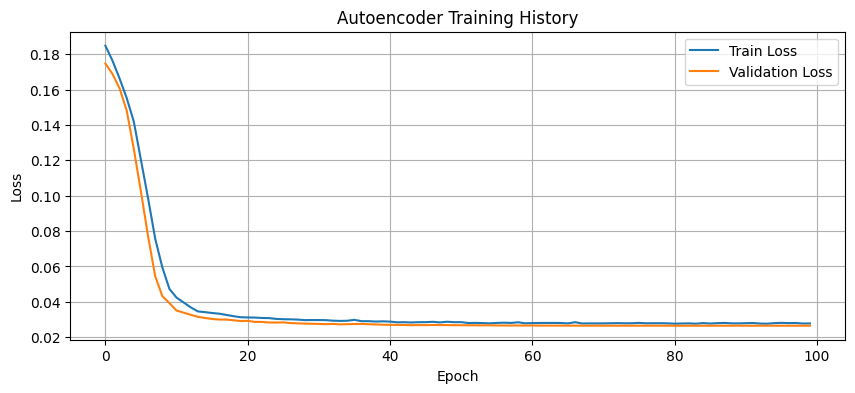


 Latent Space Özellikleri Çıkarılıyor
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

 Latent Space Üzerinde K-Means (k=5)

Cluster Alan eşleşmesi:
Küme 0 → fizik
Küme 1 → kimya
Küme 2 → kimya
Küme 3 → biyokimya
Küme 4 → dahiliye


In [ ]:
def build_autoencoder(input_dim, encoding_dim=32):
    input_layer = layers.Input(shape=(input_dim,))
    encoded = layers.Dense(256, activation='relu')(input_layer)
    encoded = layers.BatchNormalization()(encoded)
    encoded = layers.Dropout(0.3)(encoded)
    encoded = layers.Dense(128, activation='relu')(encoded)
    encoded = layers.BatchNormalization()(encoded)
    encoded = layers.Dropout(0.3)(encoded)
    encoded = layers.Dense(64, activation='relu')(encoded)
    encoded = layers.BatchNormalization()(encoded)
    latent = layers.Dense(encoding_dim, activation='relu', name='latent')(encoded)
    decoded = layers.Dense(64, activation='relu')(latent)
    decoded = layers.BatchNormalization()(decoded)
    decoded = layers.Dense(128, activation='relu')(decoded)
    decoded = layers.BatchNormalization()(decoded)
    decoded = layers.Dropout(0.3)(decoded)
    decoded = layers.Dense(256, activation='relu')(decoded)
    decoded = layers.BatchNormalization()(decoded)
    decoded = layers.Dropout(0.3)(decoded)
    output_layer = layers.Dense(input_dim, activation='sigmoid')(decoded)
    autoencoder = Model(input_layer, output_layer)
    encoder = Model(input_layer, latent)
    return autoencoder, encoder

def train_autoencoder_clustering(X, encoding_dim=32, n_clusters=5, epochs=100):
    print("\n DEEP LEARNING: Autoencoder-based Clustering")
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X.toarray() if hasattr(X, 'toarray') else X)
    from sklearn.model_selection import train_test_split
    X_train, X_val = train_test_split(X_scaled, test_size=0.2, random_state=42)
    autoencoder, encoder = build_autoencoder(X_scaled.shape[1], encoding_dim)
    autoencoder.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse'
    )

    print(f"\n Autoencoder Mimarisi:")
    autoencoder.summary()

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    )
    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6
    )
    history = autoencoder.fit(
        X_train, X_train,
        epochs=epochs,
        batch_size=32,
        validation_data=(X_val, X_val),
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Autoencoder Training History')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
    print("\n Latent Space Özellikleri Çıkarılıyor")
    latent_features = encoder.predict(X_scaled)
    print(f"\n Latent Space Üzerinde K-Means (k={n_clusters})")
    kmeans = KMeans(n_clusters=n_clusters, n_init=50, random_state=42)
    labels = kmeans.fit_predict(latent_features)
    return {
        'autoencoder': autoencoder,
        'encoder': encoder,
        'kmeans': kmeans,
        'latent_features': latent_features,
        'labels': labels,
        'scaler': scaler,
        'history': history
    }
results_deep = train_autoencoder_clustering(
    X_tfidf,
    encoding_dim=32,
    n_clusters=5,
    epochs=100
)
def create_cluster_mapping(labels, true_labels):
    mapping = {}

    df_map = pd.DataFrame({
        "cluster": labels,
        "true": true_labels
    })
    for cluster_id in sorted(df_map["cluster"].unique()):
        majority_label = (
            df_map[df_map["cluster"] == cluster_id]["true"]
            .value_counts()
            .idxmax()
        )
        mapping[cluster_id] = majority_label
    print("\nCluster Alan eşleşmesi:")
    for k, v in mapping.items():
        print(f"Küme {k} → {v}")
    return mapping
cluster_mapping = create_cluster_mapping(
    results_deep['labels'],
    df['label'].values
)


In [ ]:
def evaluate_clustering(X, labels, true_labels=None, model_name="Model"):
    print(f" {model_name} DEĞERLENDİRME")
    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    n_noise = list(labels).count(-1) if -1 in labels else 0
    print(f"\n Temel İstatistikler:")
    print(f"   Küme sayısı: {n_clusters}")
    print(f"   Noise noktalar: {n_noise}")
    print(f"\n Küme Boyutları:")
    from collections import Counter
    cluster_sizes = Counter(labels)
    for cluster_id in sorted(cluster_sizes.keys()):
        if cluster_id != -1:
            print(f"   Küme {cluster_id}: {cluster_sizes[cluster_id]} doküman")
    if n_clusters >= 2 and n_noise < len(labels):
        valid_mask = labels != -1
        X_valid = X[valid_mask] if isinstance(X, np.ndarray) else X[valid_mask].toarray()
        labels_valid = labels[valid_mask]
        sil_score = silhouette_score(X_valid, labels_valid)
        db_score = davies_bouldin_score(X_valid, labels_valid)
        ch_score = calinski_harabasz_score(X_valid, labels_valid)
        print(f"\n Internal Validation Metrics:")
        print(f"   Silhouette Score: {sil_score:.4f} ( daha iyi, [-1, 1])")
        print(f"   Davies-Bouldin Index: {db_score:.4f} ( daha iyi)")
        print(f"   Calinski-Harabasz Score: {ch_score:.2f} ( daha iyi)")
        metrics = {
            'silhouette': sil_score,
            'davies_bouldin': db_score,
            'calinski_harabasz': ch_score,
            'n_clusters': n_clusters,
            'n_noise': n_noise
        }
    else:
        print("\n Küme sayısı yetersiz, internal metrikler hesaplanamadı")
        metrics = {'n_clusters': n_clusters, 'n_noise': n_noise}
    if true_labels is not None:
        valid_mask = labels != -1

        ari = adjusted_rand_score(true_labels[valid_mask], labels[valid_mask])
        nmi = normalized_mutual_info_score(true_labels[valid_mask], labels[valid_mask])

        print(f"\n External Validation Metrics:")
        print(f"   Adjusted Rand Index: {ari:.4f} ( daha iyi, [0, 1])")
        print(f"   Normalized Mutual Info: {nmi:.4f} ( daha iyi, [0, 1])")

        metrics['ari'] = ari
        metrics['nmi'] = nmi
    return metrics

true_labels = df['label'].values
evaluation_results = {}
evaluation_results['K-Means'] = evaluate_clustering(
    X_dense, labels_kmeans, true_labels, "K-Means"
)
evaluation_results['Hierarchical'] = evaluate_clustering(
    X_dense, labels_hierarchical, true_labels, "Hierarchical Clustering"
)
evaluation_results['DBSCAN'] = evaluate_clustering(
    X_dense, labels_dbscan, true_labels, "DBSCAN"
)
evaluation_results['GMM'] = evaluate_clustering(
    X_dense, labels_gmm, true_labels, "Gaussian Mixture Model"
)
evaluation_results['Autoencoder'] = evaluate_clustering(
    results_deep['latent_features'],
    results_deep['labels'],
    true_labels,
    "Autoencoder + K-Means"
)

 K-Means DEĞERLENDİRME

 Temel İstatistikler:
   Küme sayısı: 5
   Noise noktalar: 0

 Küme Boyutları:
   Küme 0: 129 doküman
   Küme 1: 175 doküman
   Küme 2: 58 doküman
   Küme 3: 160 doküman
   Küme 4: 12 doküman

 Internal Validation Metrics:
   Silhouette Score: 0.1001 ( daha iyi, [-1, 1])
   Davies-Bouldin Index: 2.6989 ( daha iyi)
   Calinski-Harabasz Score: 31.41 ( daha iyi)

 External Validation Metrics:
   Adjusted Rand Index: 0.4175 ( daha iyi, [0, 1])
   Normalized Mutual Info: 0.5004 ( daha iyi, [0, 1])
 Hierarchical Clustering DEĞERLENDİRME

 Temel İstatistikler:
   Küme sayısı: 5
   Noise noktalar: 0

 Küme Boyutları:
   Küme 0: 140 doküman
   Küme 1: 185 doküman
   Küme 2: 135 doküman
   Küme 3: 60 doküman
   Küme 4: 14 doküman

 Internal Validation Metrics:
   Silhouette Score: 0.0921 ( daha iyi, [-1, 1])
   Davies-Bouldin Index: 2.8338 ( daha iyi)
   Calinski-Harabasz Score: 29.06 ( daha iyi)

 External Validation Metrics:
   Adjusted Rand Index: 0.3317 ( daha iyi, [0

**Değerlendirme**

In [ ]:
def evaluate_clustering(X, labels, true_labels=None, model_name="Model"):
    print(f" {model_name} DEĞERLENDİRME")
    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    n_noise = list(labels).count(-1) if -1 in labels else 0
    print(f"\n Temel İstatistikler:")
    print(f"   Küme sayısı: {n_clusters}")
    print(f"   Noise noktalar: {n_noise}")
    print(f"\n Küme Boyutları:")
    from collections import Counter
    cluster_sizes = Counter(labels)
    for cluster_id in sorted(cluster_sizes.keys()):
        if cluster_id != -1:
            print(f"   Küme {cluster_id}: {cluster_sizes[cluster_id]} doküman")
    if n_clusters >= 2 and n_noise < len(labels):
        valid_mask = labels != -1
        X_valid = X[valid_mask] if isinstance(X, np.ndarray) else X[valid_mask].toarray()
        labels_valid = labels[valid_mask]

        sil_score = silhouette_score(X_valid, labels_valid)
        db_score = davies_bouldin_score(X_valid, labels_valid)
        ch_score = calinski_harabasz_score(X_valid, labels_valid)

        print(f"\n Internal Validation Metrics:")
        print(f"   Silhouette Score: {sil_score:.4f} ( daha iyi, [-1, 1])")
        print(f"   Davies-Bouldin Index: {db_score:.4f} ( daha iyi)")
        print(f"   Calinski-Harabasz Score: {ch_score:.2f} ( daha iyi)")

        metrics = {
            'silhouette': sil_score,
            'davies_bouldin': db_score,
            'calinski_harabasz': ch_score,
            'n_clusters': n_clusters,
            'n_noise': n_noise
        }
    else:
        print("\n Küme sayısı yetersiz, internal metrikler hesaplanamadı")
        metrics = {'n_clusters': n_clusters, 'n_noise': n_noise}
    if true_labels is not None:
        valid_mask = labels != -1

        ari = adjusted_rand_score(true_labels[valid_mask], labels[valid_mask])
        nmi = normalized_mutual_info_score(true_labels[valid_mask], labels[valid_mask])

        print(f"\n External Validation Metrics:")
        print(f"   Adjusted Rand Index: {ari:.4f} ( daha iyi, [0, 1])")
        print(f"   Normalized Mutual Info: {nmi:.4f} ( daha iyi, [0, 1])")

        metrics['ari'] = ari
        metrics['nmi'] = nmi
    return metrics

true_labels = df['label'].values
evaluation_results = {}
evaluation_results['K-Means'] = evaluate_clustering(
    X_dense, labels_kmeans, true_labels, "K-Means"
)
evaluation_results['Hierarchical'] = evaluate_clustering(
    X_dense, labels_hierarchical, true_labels, "Hierarchical Clustering"
)
evaluation_results['DBSCAN'] = evaluate_clustering(
    X_dense, labels_dbscan, true_labels, "DBSCAN"
)
evaluation_results['GMM'] = evaluate_clustering(
    X_dense, labels_gmm, true_labels, "Gaussian Mixture Model"
)
evaluation_results['Autoencoder'] = evaluate_clustering(
    results_deep['latent_features'],
    results_deep['labels'],
    true_labels,
    "Autoencoder + K-Means"
)

 K-Means DEĞERLENDİRME

 Temel İstatistikler:
   Küme sayısı: 5
   Noise noktalar: 0

 Küme Boyutları:
   Küme 0: 95 doküman
   Küme 1: 116 doküman
   Küme 2: 66 doküman
   Küme 3: 147 doküman
   Küme 4: 110 doküman

 Internal Validation Metrics:
   Silhouette Score: 0.1881 ( daha iyi, [-1, 1])
   Davies-Bouldin Index: 2.1039 ( daha iyi)
   Calinski-Harabasz Score: 93.85 ( daha iyi)

 External Validation Metrics:
   Adjusted Rand Index: 0.4554 ( daha iyi, [0, 1])
   Normalized Mutual Info: 0.5382 ( daha iyi, [0, 1])
 Hierarchical Clustering DEĞERLENDİRME

 Temel İstatistikler:
   Küme sayısı: 5
   Noise noktalar: 0

 Küme Boyutları:
   Küme 0: 128 doküman
   Küme 1: 126 doküman
   Küme 2: 118 doküman
   Küme 3: 66 doküman
   Küme 4: 96 doküman

 Internal Validation Metrics:
   Silhouette Score: 0.1660 ( daha iyi, [-1, 1])
   Davies-Bouldin Index: 2.1588 ( daha iyi)
   Calinski-Harabasz Score: 88.61 ( daha iyi)

 External Validation Metrics:
   Adjusted Rand Index: 0.4516 ( daha iyi, [0

 MODEL KARŞILAŞTIRMASI

 Detaylı Karşılaştırma:
              silhouette  davies_bouldin  calinski_harabasz  n_clusters  n_noise       ari       nmi
DBSCAN          0.896927        0.209431         266.951942        63.0    404.0  0.014742  0.355300
Autoencoder     0.352229        1.075467         425.155762         5.0      0.0  0.455573  0.504882
GMM             0.197041        2.107831          84.243671         5.0      0.0  0.336904  0.455812
K-Means         0.187991        2.101672          93.932871         5.0      0.0  0.455355  0.538202
Hierarchical    0.171305        2.203209          89.491803         5.0      0.0  0.447414  0.512786

 EN İYİ MODEL: DBSCAN
   Silhouette Score: 0.8969
   Adjusted Rand Index: 0.0147


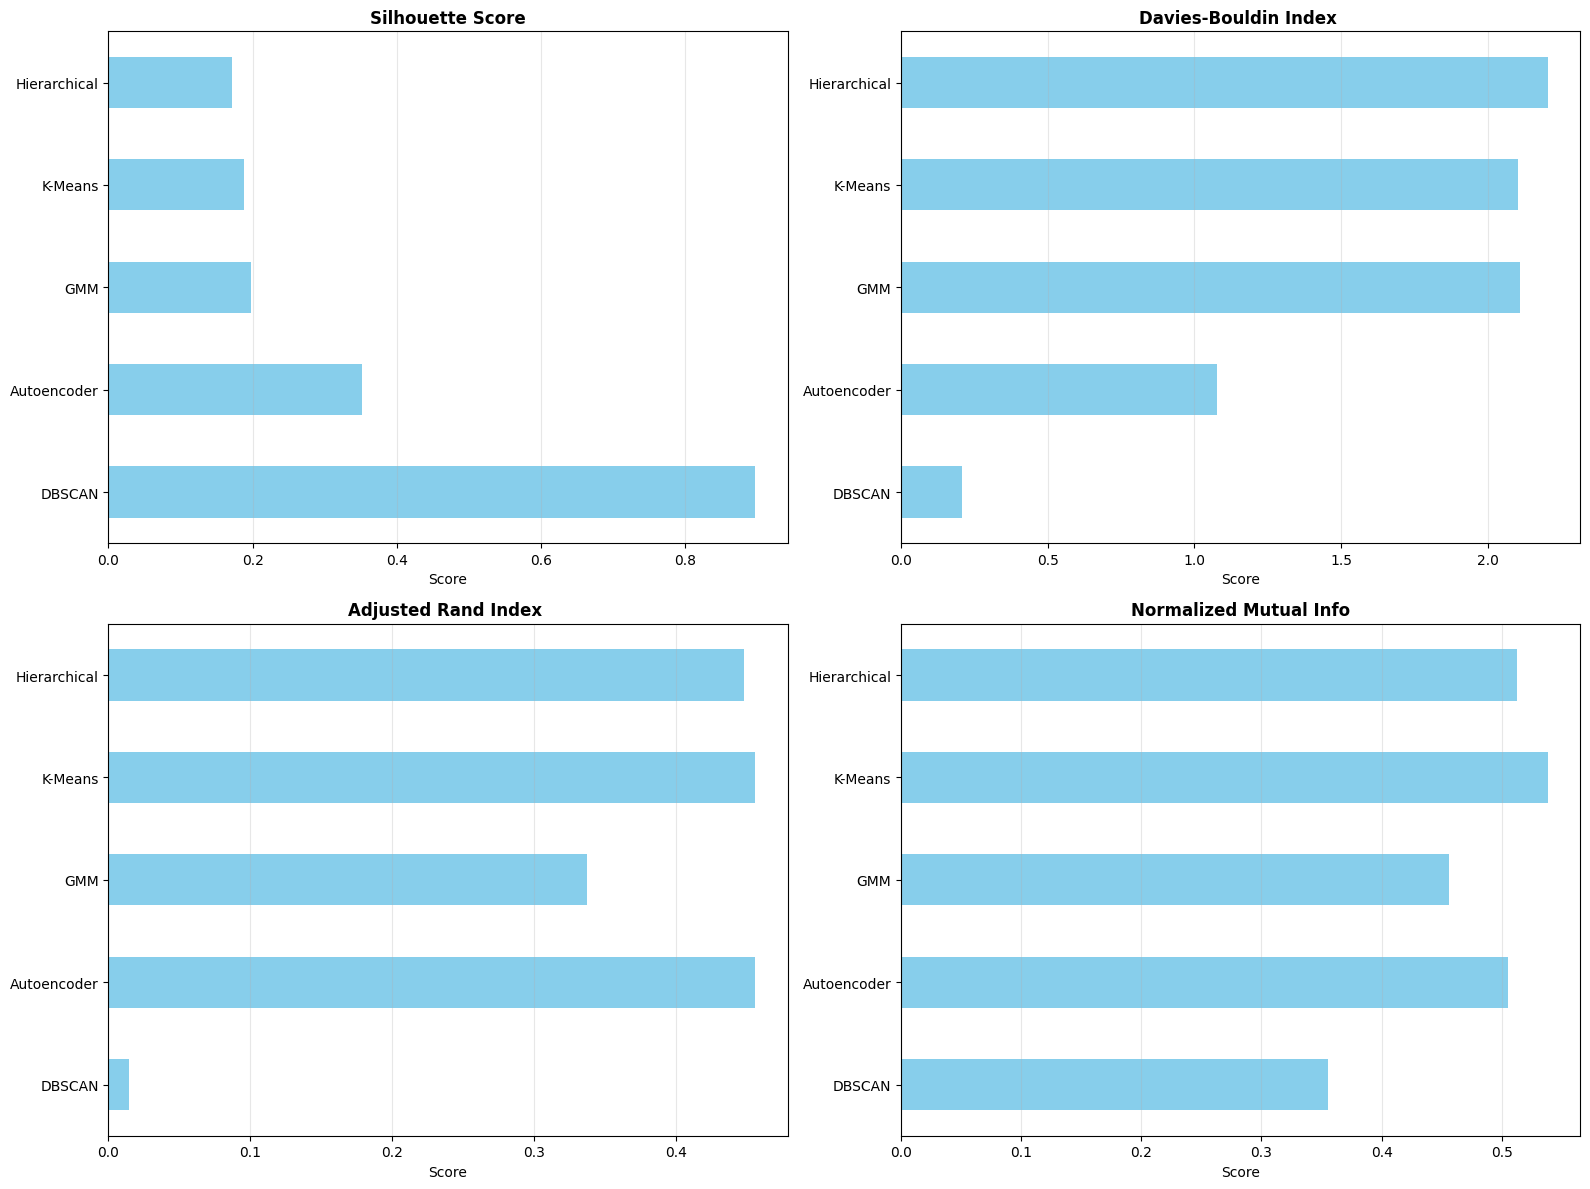

In [ ]:
def compare_models(evaluation_results):
    print(" MODEL KARŞILAŞTIRMASI")
    comparison_df = pd.DataFrame(evaluation_results).T
    if 'silhouette' in comparison_df.columns:
        comparison_df = comparison_df.sort_values('silhouette', ascending=False)
    print("\n Detaylı Karşılaştırma:")
    print(comparison_df.to_string())
    if 'silhouette' in comparison_df.columns:
        best_model = comparison_df['silhouette'].idxmax()
        print(f"\n EN İYİ MODEL: {best_model}")
        print(f"   Silhouette Score: {comparison_df.loc[best_model, 'silhouette']:.4f}")
        if 'ari' in comparison_df.columns:
            print(f"   Adjusted Rand Index: {comparison_df.loc[best_model, 'ari']:.4f}")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    metrics_to_plot = ['silhouette', 'davies_bouldin', 'ari', 'nmi']
    metric_titles = ['Silhouette Score', 'Davies-Bouldin Index ',
                     'Adjusted Rand Index ', 'Normalized Mutual Info']
    for idx, (metric, title) in enumerate(zip(metrics_to_plot, metric_titles)):
        ax = axes[idx // 2, idx % 2]
        if metric in comparison_df.columns:
            comparison_df[metric].plot(kind='barh', ax=ax, color='skyblue')
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.set_xlabel('Score')
            ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    return comparison_df
comparison_table = compare_models(evaluation_results)


 t-SNE Görselleştirmesi: DBSCAN


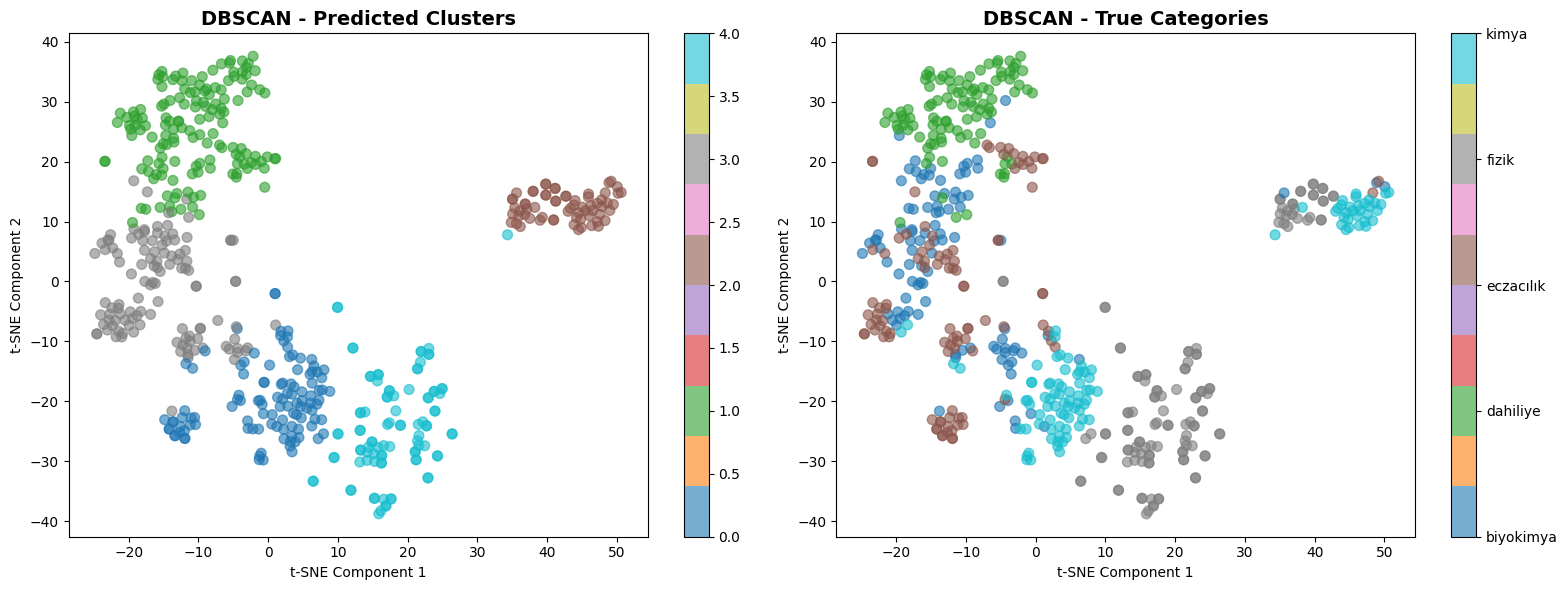

In [ ]:
def visualize_clusters_tsne(X, labels, true_labels, title="Cluster Visualization"):
    print(f"\n t-SNE Görselleştirmesi: {title}")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_2d = tsne.fit_transform(X)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    scatter1 = axes[0].scatter(
        X_2d[:, 0], X_2d[:, 1],
        c=labels,
        cmap='tab10',
        alpha=0.6,
        s=50
    )
    axes[0].set_title(f'{title} - Predicted Clusters', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('t-SNE Component 1')
    axes[0].set_ylabel('t-SNE Component 2')
    plt.colorbar(scatter1, ax=axes[0])
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    true_labels_encoded = le.fit_transform(true_labels)
    scatter2 = axes[1].scatter(
        X_2d[:, 0], X_2d[:, 1],
        c=true_labels_encoded,
        cmap='tab10',
        alpha=0.6,
        s=50
    )
    axes[1].set_title(f'{title} - True Categories', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('t-SNE Component 1')
    axes[1].set_ylabel('t-SNE Component 2')
    cbar = plt.colorbar(scatter2, ax=axes[1])
    cbar.set_ticks(range(len(le.classes_)))
    cbar.set_ticklabels(le.classes_)

    plt.tight_layout()
    plt.show()
best_model_name = comparison_table['silhouette'].idxmax()

if best_model_name == 'Autoencoder':
    visualize_clusters_tsne(
        results_deep['latent_features'],
        results_deep['labels'],
        true_labels,
        "Autoencoder + K-Means"
    )
else:
    visualize_clusters_tsne(
        X_dense,
        labels_kmeans,
        true_labels,
        best_model_name
    )

In [ ]:
import pickle
import joblib
def save_models(results_classical, results_deep, output_dir='/content/drive/MyDrive/clustering_models/'):
    import os
    os.makedirs(output_dir, exist_ok=True)
    joblib.dump(results_classical['kmeans'], f'{output_dir}kmeans_model.pkl')
    joblib.dump(results_classical['hierarchical'], f'{output_dir}hierarchical_model.pkl')
    joblib.dump(results_classical['dbscan'], f'{output_dir}dbscan_model.pkl')
    joblib.dump(results_classical['gmm'], f'{output_dir}gmm_model.pkl')
    joblib.dump(tfidf_vectorizer, f'{output_dir}tfidf_vectorizer.pkl')
    results_deep['autoencoder'].save(f'{output_dir}autoencoder_model.h5')
    results_deep['encoder'].save(f'{output_dir}encoder_model.h5')
    joblib.dump(results_deep['kmeans'], f'{output_dir}autoencoder_kmeans.pkl')
    joblib.dump(results_deep['scaler'], f'{output_dir}scaler.pkl')
    print(f" Tüm modeller '{output_dir}' dizinine kaydedildi")

save_models(results_classical, results_deep)
def predict_cluster(new_text, model_type='autoencoder'):
    if model_type == 'autoencoder':
        tfidf_vec = tfidf_vectorizer.transform([new_text])
        scaled = results_deep['scaler'].transform(tfidf_vec.toarray())
        latent = results_deep['encoder'].predict(scaled)
        cluster = results_deep['kmeans'].predict(latent)[0]
    else:
        tfidf_vec = tfidf_vectorizer.transform([new_text])
        pca_features = pca.transform(tfidf_vec.toarray())
        cluster = results_classical['kmeans'].predict(pca_features)[0]

    return cluster, cluster_mapping[cluster]
cluster_id, area = predict_cluster(test_text)
print(f"\nTest Metni: '{test_text}'")
print(f"Küme: {cluster_id}")
print(f"Alan: {area}")


 Tüm modeller '/content/drive/MyDrive/clustering_models/' dizinine kaydedildi
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step

Test Metni: 'Titanyum dioksit nanopartiküllerin sentezi ve karakterizasyonu'
Küme: 1
Alan: kimya
